In [1]:
from pathlib import Path

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from core import Config
import pandas as pd

config = Config()
DATA_PATH: Path = config.training_dir / "baseline.csv"
# variables
DEPTH = 16
RESULTS_NAME = "metrics_catboost_baseline_depth_16"
SHAP_NAME = "shap_importance_" + RESULTS_NAME + ".csv"
SHAP_PLOT_NAME = "shap_beeswarm_" + RESULTS_NAME + ".png"

all_data: pd.DataFrame = pd.read_csv(DATA_PATH, index_col=0)

In [2]:
training_data = all_data.copy()
training_data.drop(
    training_data[training_data["TR.UpstreamScope3PurchasedGoodsAndServices"].isna()].index,
    inplace=True
)
y: pd.DataFrame = training_data['TR.UpstreamScope3PurchasedGoodsAndServices'].to_frame()
X: pd.DataFrame = training_data.drop('TR.UpstreamScope3PurchasedGoodsAndServices', axis=1)
# date could also be a categorical variable
cat_cols = ["Instrument", "Date", "TR.GICSSectorCode", "TR.HQCountryCode"]
cat_cols.remove("Instrument")
X[cat_cols] = X[cat_cols].astype("str")

In [3]:
from typing import cast
from sklearn.model_selection import GroupKFold
from catboost import Pool, CatBoostRegressor

gkf: GroupKFold = GroupKFold(n_splits=5)
fold_results: list[dict] = []

best_fold_index: int | None = None
best_metric_value: float | None = None  # lower is better (RMSE)
best_model: CatBoostRegressor | None = None
best_X_val: pd.DataFrame | None = None
best_y_val: pd.Series | None = None

for fold_index, (train_index, val_index) in enumerate(gkf.split(X, y, groups=X['Instrument']), start=1):
    print(f"Fold {fold_index}")
    X_without_instrument = X.drop(columns=["Instrument"])
    X_train: pd.DataFrame = cast(pd.DataFrame, X_without_instrument.iloc[train_index])
#    X_train: pd.DataFrame = cast(pd.DataFrame, X.iloc[train_index])
    X_val: pd.DataFrame = cast(pd.DataFrame, X_without_instrument.iloc[val_index])
#    X_val: pd.DataFrame = cast(pd.DataFrame, X.iloc[val_index])
    y_train: pd.Series[float] = cast(pd.Series, y.iloc[train_index])
    y_val: pd.Series[float] = cast(pd.Series, y.iloc[val_index])

    train_pool: Pool = Pool(
        data=X_train,
        label=y_train,
        cat_features=cat_cols
    )

    val_pool: Pool = Pool(
        data=X_val,
        label=y_val,
        cat_features=cat_cols
    )

    model = CatBoostRegressor(
        iterations=100,
        learning_rate=0.05,
        depth=DEPTH,
        loss_function='RMSE',
        use_best_model=True,
        verbose=False
    )

    model.fit(
        train_pool,
        eval_set=val_pool,
    )

    y_val_pred: list[float] = model.predict(val_pool)

    rmse: float = float(np.sqrt(mean_squared_error(y_val, y_val_pred)))
    mae: float = cast(float, mean_absolute_error(y_val, y_val_pred))
    r2: float = r2_score(y_val, y_val_pred)

    best_iter = model.get_best_iteration()

    fold_results.append(
        {
            "model_name": "catboost_baseline",
            "fold": fold_index,
            "sector": "All",
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
        }
    )

    # update best model based on RMSE
    if (best_metric_value is None) or (rmse < best_metric_value):
        best_metric_value = rmse
        best_fold_index = fold_index
        best_model = model
        best_X_val = X_val.copy()
        best_y_val = y_val.copy()

    val_sectors: pd.Series = X_val["TR.GICSSectorCode"].astype("category")

    val_sectors = X_val["TR.GICSSectorCode"]
    val_df: pd.DataFrame = pd.DataFrame(
        {
            "y_true": y_val.to_numpy().ravel(),
            "y_pred": y_val_pred,
            "sector": val_sectors.to_numpy().ravel(),
        }
    )

    for sector, grp in val_df.groupby("sector"):
        rmse = float(np.sqrt(mean_squared_error(grp["y_true"], grp["y_pred"])))
        mae = cast(float, mean_absolute_error(grp["y_true"], grp["y_pred"]))
        r2 = r2_score(grp["y_true"], grp["y_pred"])

        fold_results.append(
            {
                "model_name": "catboost_baseline",
                "fold": fold_index,
                "sector": sector,
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
            }
        )

print(f"Best fold by RMSE: {best_fold_index} (RMSE={best_metric_value:.2f})")
metrics_df: pd.DataFrame = pd.DataFrame(fold_results)

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Best fold by RMSE: 2 (RMSE=9814818.86)


In [4]:
METRICS_PATH: Path = config.results_dir / RESULTS_NAME
metrics_df.to_csv(METRICS_PATH, index=False)

In [5]:
# ---- SHAP for best fold only ----
assert best_model is not None
assert best_X_val is not None
assert best_y_val is not None

best_val_pool: Pool = Pool(
    data=best_X_val,
    label=best_y_val,
    cat_features=cat_cols,
)

feature_names = best_model.feature_names_

shap_values = best_model.get_feature_importance(
    data=best_val_pool,
    type="ShapValues",
)

# drop expected value column
shap_contribs = shap_values[:, :-1]

shap_best_df = pd.DataFrame(
    shap_contribs,
    columns=feature_names,
    index=best_X_val.index,
)

# mean absolute SHAP over all validation observations of the best fold
shap_best_importance = shap_best_df.abs().mean(axis=0).sort_values(ascending=False)

shap_best_with_sector = shap_best_df.copy()
shap_best_with_sector["sector"] = best_X_val["TR.GICSSectorCode"].astype(str).values

feature_cols = [c for c in shap_best_with_sector.columns if c != "sector"]

# mean absolute SHAP per feature, per sector
shap_sector_best = (
    shap_best_with_sector[feature_cols]
    .abs()
    .groupby(shap_best_with_sector["sector"])
    .mean()
)

# combine shap_sector_best with shap_best_importance
shap_best_row = shap_best_importance.to_frame().T
shap_best_row.index = ["All"]
shap_best_row = shap_best_row[shap_sector_best.columns]
shap_importance_with_all = pd.concat(
    [shap_sector_best, shap_best_row],
    axis=0,
)

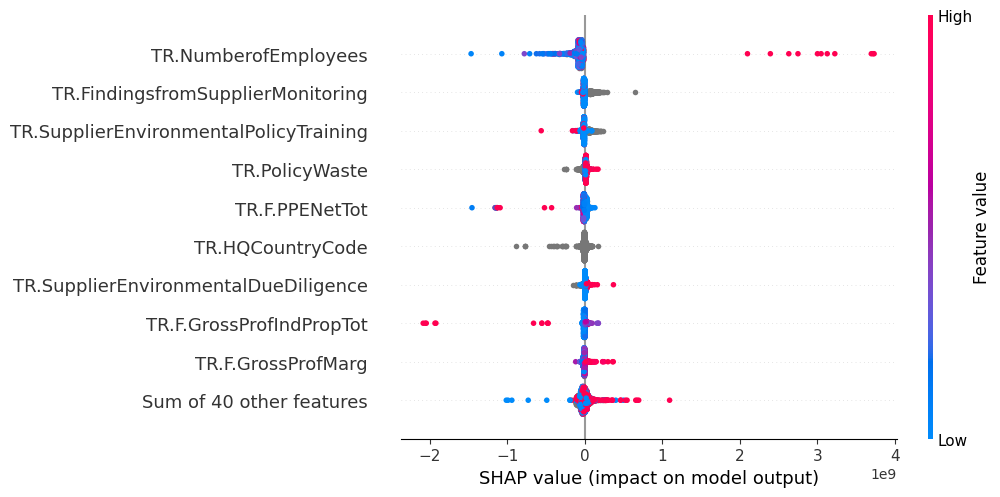

<Figure size 640x480 with 0 Axes>

In [6]:
import shap
import matplotlib.pyplot as plt

expl = shap.Explanation(
    values=shap_contribs,
    base_values=shap_values[:, -1],
    data=best_X_val[feature_names].to_numpy(),
    feature_names=feature_names,
)
plt.figure(figsize=(8, 6))
shap.plots.beeswarm(expl, max_display=10)
fig = plt.gcf()

fig.savefig(
    config.results_dir / SHAP_PLOT_NAME,
    bbox_inches="tight",
    dpi=300,
    format="png"
)

In [7]:
metrics_df.groupby(["sector"]).agg(
    {
        "rmse": ["mean", "std"],
        "mae": ["mean", "std"],
        "r2": ["mean", "std"]
    }
)

rmse                         mae                         r2  \
                mean           std          mean           std         mean   
sector                                                                        
10      2.141571e+07  2.197407e+07  1.370064e+07  1.026804e+07    -4.924993   
15      1.055484e+07  5.688653e+06  8.026022e+06  6.154791e+06    -4.120808   
20      6.639856e+09  1.481930e+10  3.165064e+08  6.877069e+08   -16.713156   
25      1.517815e+07  4.661851e+06  8.442753e+06  5.220110e+06    -2.421847   
30      1.941085e+07  1.346027e+07  1.005577e+07  5.825698e+06    -0.024867   
35      8.072212e+06  6.931650e+06  6.531763e+06  6.799657e+06   -13.191117   
40      1.686115e+07  1.664466e+07  7.843941e+06  6.538396e+06 -1372.367069   
45      9.236400e+06  5.791921e+06  6.961953e+06  6.022005e+06   -11.605788   
50      1.041654e+07  7.663548e+06  8.678735e+06  7.687508e+06  -248.030971   
55      1.305412e+07  8.168061e+06  1.150312e+07  7.984585e+06   -34.342907   
60      9.994162e+06  7.111617e+06  8.402040e+06  6.917971e+06 -1981.612960   
All     3.027755e+09  6.733002e+09  7.211708e+07  1.398479e+08    -2.369917   

                     
                std  
sector               
10         9.171904  
15         7.188191  
20        24.972188  
25         2.460320  
30         0.262460  
35        18.901150  
40      1811.116112  
45        14.163379  
50       414.662062  
55        47.964097  
60      3757.760221  
All        3.230173

In [8]:
shap_importance_with_all.to_csv(config.results_dir / SHAP_NAME)